# DS 4320 Project 1 Pipeline
## Predicting NFL Pregame Home-Team Win Probability

This notebook loads the finished project tables from parquet files, stores them in DuckDB, runs SQL queries, trains machine-learning models, evaluates performance, and visualizes the results.

### Main pipeline steps
1. Load the four project tables from parquet files
2. Load the data into DuckDB
3. Use SQL to inspect and summarize the tables
4. Prepare a modeling table using pregame rolling, market, and schedule-context features
5. Drop very early-season games where rolling features are too noisy
6. Train a logistic-regression baseline
7. Train a random-forest comparison model
8. Evaluate the models on held-out future seasons
9. Create project figures

## Imports, paths, logging, and setup

This notebook uses the parquet files created by `build_project_tables.py`. It also creates a few folders if they do not already exist, including a folder for figures and a folder for log files.

In [1]:
from pathlib import Path
import logging

import pandas as pd
import matplotlib.pyplot as plt
import duckdb

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# make sure output folders exist before saving files
Path("figures").mkdir(parents=True, exist_ok=True)
Path("pipeline/logs").mkdir(parents=True, exist_ok=True)

# logging
logging.basicConfig(
    filename="pipeline/logs/train_models.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logging.info("Started project_1_pipeline.ipynb.")

# use a time-based split instead of random shuffling
# this better matches real forecasting
TRAIN_SEASONS = list(range(2010, 2022))
VALID_SEASONS = [2022]
TEST_SEASONS = [2023, 2024]

## Load the four project tables from parquet

These parquet files were created by `build_project_tables.py` and exported from DuckDB. They form the final project dataset.

In [2]:
teams = pd.read_parquet("data/teams.parquet")
games = pd.read_parquet("data/games.parquet")
team_games = pd.read_parquet("data/team_games.parquet")
matchups = pd.read_parquet("data/matchups.parquet")

# make sure game dates are treated as datetimes if needed
if "gameday" in games.columns:
    games["gameday"] = pd.to_datetime(games["gameday"])

if "gameday" in team_games.columns:
    team_games["gameday"] = pd.to_datetime(team_games["gameday"])

if "gameday" in matchups.columns:
    matchups["gameday"] = pd.to_datetime(matchups["gameday"])

print("teams:", teams.shape)
print("games:", games.shape)
print("team_games:", team_games.shape)
print("matchups:", matchups.shape)

logging.info("Loaded all four project parquet tables.")

teams: (32, 5)
games: (3903, 25)
team_games: (7806, 24)
matchups: (3903, 56)


## Load Tables into DuckDB

This shows how the project data can be loaded into a database and queried using SQL.

In [3]:
# connect to duckdb using a local database file
con = duckdb.connect("data/project_1.duckdb")

# register pandas dataframes so duckdb can query them
con.register("teams_df", teams)
con.register("games_df", games)
con.register("team_games_df", team_games)
con.register("matchups_df", matchups)

# connect to duckdb using a local database file
con.execute("CREATE OR REPLACE TABLE teams AS SELECT * FROM teams_df")
con.execute("CREATE OR REPLACE TABLE games AS SELECT * FROM games_df")
con.execute("CREATE OR REPLACE TABLE team_games AS SELECT * FROM team_games_df")
con.execute("CREATE OR REPLACE TABLE matchups AS SELECT * FROM matchups_df")

logging.info("Loaded project tables into DuckDB.")

print("DuckDB tables created successfully.")

DuckDB tables created successfully.


## SQL Query 1: Season-Level Home-Win Summary

This query gives a high-level summary of how often the home team wins in each season and what average scoring looks like.

In [4]:
# summarize how often home teams win by season
query_1 = """
SELECT
    season,
    COUNT(*) AS games_n,
    AVG(home_win) AS home_win_rate,
    AVG(home_score) AS avg_home_score,
    AVG(away_score) AS avg_away_score
FROM games
GROUP BY season
ORDER BY season;
"""

# run the sql query and store the result as a pandas dataframe
home_win_rate_by_season = con.execute(query_1).df()
home_win_rate_by_season

,season,games_n,home_win_rate,avg_home_score,avg_away_score
0,2010,256,0.558594,22.984375,21.089844
1,2011,256,0.566406,23.812500,20.546875
2,2012,256,0.570312,23.972656,21.539062
3,2013,256,0.597656,24.960938,21.855469
4,2014,256,0.566406,23.832031,21.343750
5,2015,256,0.539062,23.593750,22.031250
6,2016,256,0.574219,24.058594,21.492188
7,2017,256,0.566406,22.960938,20.476562
8,2018,256,0.597656,24.445312,22.242188
9,2019,256,0.515625,22.742188,22.882812


## SQL Query 2: Spread Bucket Analysis

This query checks how strongly the pregame point spread lines up with actual home-team win rates.

In [5]:
# group games by spread bucket and compare to actual home win rate
query_2 = """
SELECT
    CASE
        WHEN spread_line >= 7 THEN 'home_favored_7_plus'
        WHEN spread_line >= 3 AND spread_line < 7 THEN 'home_favored_3_to_6_5'
        WHEN spread_line > 0 AND spread_line < 3 THEN 'home_favored_under_3'
        WHEN spread_line = 0 THEN 'pickem'
        WHEN spread_line < 0 AND spread_line > -3 THEN 'away_favored_under_3'
        WHEN spread_line <= -3 AND spread_line > -7 THEN 'away_favored_3_to_6_5'
        WHEN spread_line <= -7 THEN 'away_favored_7_plus'
        ELSE 'missing_spread'
    END AS spread_bucket,
    COUNT(*) AS games_n,
    AVG(target_home_win) AS home_win_rate
FROM matchups
GROUP BY spread_bucket
ORDER BY games_n DESC;
"""

spread_bucket_summary = con.execute(query_2).df()
spread_bucket_summary

,spread_bucket,games_n,home_win_rate
0,home_favored_3_to_6_5,1158,0.639896
1,home_favored_7_plus,840,0.809524
2,away_favored_3_to_6_5,741,0.345479
3,home_favored_under_3,465,0.509677
4,away_favored_under_3,408,0.448529
5,away_favored_7_plus,287,0.212544
6,pickem,4,0.750000


## SQL Query 3: Recent-Form Advantage and Home-Team Win Rate

This query checks whether the home team tends to win more often when it enters the game with better recent point-differential form over the previous three games.

In [6]:
# compare recent-form advantage to actual home-team win rate
query_3 = """
SELECT
    CASE
        WHEN last3_point_diff_pg_diff < 0 THEN 'home_recent_form_worse'
        WHEN last3_point_diff_pg_diff = 0 THEN 'recent_form_equal'
        WHEN last3_point_diff_pg_diff > 0 THEN 'home_recent_form_better'
    END AS recent_form_group,
    COUNT(*) AS games_n,
    AVG(target_home_win) AS home_win_rate
FROM matchups
GROUP BY recent_form_group
ORDER BY games_n DESC;
"""

recent_form_summary = con.execute(query_3).df()
recent_form_summary

,recent_form_group,games_n,home_win_rate
0,home_recent_form_worse,2033,0.462371
1,home_recent_form_better,1836,0.650871
2,recent_form_equal,34,0.764706


## Prepare modeling inputs

The model uses only pregame variables. Final score columns are not used as predictors because they would leak the answer.

I also drop games from weeks 1 and 2 because rolling features are especially noisy at the very beginning of a season.

In [7]:
# choose the predictor columns for the model
# these are all pregame features only

feature_cols = [
    # rolling team form
    "home_pregame_win_pct",
    "away_pregame_win_pct",
    "home_pregame_points_for_pg",
    "away_pregame_points_for_pg",
    "home_pregame_points_against_pg",
    "away_pregame_points_against_pg",
    "home_pregame_point_diff_pg",
    "away_pregame_point_diff_pg",
    "pregame_win_pct_diff",
    "pregame_points_for_pg_diff",
    "pregame_points_against_pg_diff",
    "pregame_point_diff_pg_diff",

    # cumulative counts
    "home_games_played_before",
    "away_games_played_before",
    "home_cum_wins_before",
    "away_cum_wins_before",
    "home_cum_losses_before",
    "away_cum_losses_before",
    "games_played_before_diff",
    "cum_wins_before_diff",
    "cum_losses_before_diff",

    # recent form
    "home_pregame_last3_win_pct",
    "away_pregame_last3_win_pct",
    "home_pregame_last3_point_diff_pg",
    "away_pregame_last3_point_diff_pg",
    "last3_win_pct_diff",
    "last3_point_diff_pg_diff",

    # schedule / market context
    "home_rest",
    "away_rest",
    "sched_rest_diff",
    "home_days_rest_calc",
    "away_days_rest_calc",
    "calc_rest_diff",
    "spread_line",
    "total_line",
    "home_moneyline",
    "away_moneyline",
    "market_home_implied_prob",
    "market_away_implied_prob",
    "market_implied_prob_diff",
    "div_game",
    "temp",
    "wind"
]

# drop weeks 1 and 2 because rolling features are especially noisy there
model_df = matchups.loc[matchups["week"] >= 3].copy()
# keep only the columns needed for modeling
model_df = model_df[["season", "week", "game_id", "target_home_win"] + feature_cols]

# create train, validation, and test sets by season
train_df = model_df.loc[model_df["season"].isin(TRAIN_SEASONS)].copy()
valid_df = model_df.loc[model_df["season"].isin(VALID_SEASONS)].copy()
test_df = model_df.loc[model_df["season"].isin(TEST_SEASONS)].copy()

# split into x features and y target
X_train = train_df[feature_cols]
y_train = train_df["target_home_win"]

X_valid = valid_df[feature_cols]
y_valid = valid_df["target_home_win"]

X_test = test_df[feature_cols]
y_test = test_df["target_home_win"]

print("train rows:", len(train_df))
print("validation rows:", len(valid_df))
print("test rows:", len(test_df))

train rows: 2705
validation rows: 239
test rows: 480


## Baseline for context

Before evaluating the machine-learning models, I calculate a simple baseline that always predicts the majority class from the training data.

In [13]:
# create a simple majority-class baseline
# this predicts the most common class from training data

home_win_rate_train = y_train.mean()
baseline_preds = [1 if home_win_rate_train >= 0.5 else 0] * len(y_test)

print("baseline test accuracy:", accuracy_score(y_test, baseline_preds))
print("training home win rate:", home_win_rate_train)

baseline test accuracy: 0.5541666666666667
training home win rate: 0.5508317929759704


## Preprocessing

All current modeling features are numeric, so I use median imputation for missing values. Logistic regression also uses scaling because it is a linear model and is more stable when features are on comparable scales. Random forest does not require feature scaling, so I only use median imputation there.

I chose these two models because they fit the prediction goal well. Logistic regression is a strong baseline for a binary outcome like home-team win probability because it is interpretable and standard for classification. Random forest is a good nonlinear comparison model for structured NFL tabular data because it can capture interactions and nonlinear effects among pregame features that logistic regression may miss.

In [14]:
# preprocessing for logistic regression
# impute missing values, then scale features
numeric_preprocessor_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# preprocessing for random forest
# impute missing values only
# trees do not need scaling
numeric_preprocessor_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

## Model 1: Logistic Regression

I am starting with logistic regression because it is a standard, interpretable model for binary classification.

In [16]:
logit_model = Pipeline([
    ("prep", numeric_preprocessor_scaled),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

logit_model.fit(X_train, y_train)

# predict class probabilities for validation and test
valid_logit_probs = logit_model.predict_proba(X_valid)[:, 1]
test_logit_probs = logit_model.predict_proba(X_test)[:, 1]

# convert probabilities to 0/1 predictions using 0.5 threshold
valid_logit_preds = (valid_logit_probs >= 0.5).astype(int)
test_logit_preds = (test_logit_probs >= 0.5).astype(int)

print("logistic regression validation accuracy:", accuracy_score(y_valid, valid_logit_preds))
print("logistic regression validation ROC AUC:", roc_auc_score(y_valid, valid_logit_probs))
print("logistic regression test accuracy:", accuracy_score(y_test, test_logit_preds))
print("logistic regression test ROC AUC:", roc_auc_score(y_test, test_logit_probs))

logistic regression validation accuracy: 0.6694560669456067
logistic regression validation ROC AUC: 0.7160625444207533
logistic regression test accuracy: 0.7083333333333334
logistic regression test ROC AUC: 0.7481378680345724


## Model 2: Random Forest Model

I'm comparing the baseline and logistic regression model to a random forest model so that the project can consider using a more flexible machine-learning method as well.

In [17]:
rf_model = Pipeline([
    ("prep", numeric_preprocessor_unscaled),
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

valid_rf_probs = rf_model.predict_proba(X_valid)[:, 1]
test_rf_probs = rf_model.predict_proba(X_test)[:, 1]

valid_rf_preds = (valid_rf_probs >= 0.5).astype(int)
test_rf_preds = (test_rf_probs >= 0.5).astype(int)

print("random forest validation accuracy:", accuracy_score(y_valid, valid_rf_preds))
print("random forest validation ROC AUC:", roc_auc_score(y_valid, valid_rf_probs))
print("random forest test accuracy:", accuracy_score(y_test, test_rf_preds))
print("random forest test ROC AUC:", roc_auc_score(y_test, test_rf_probs))

random forest validation accuracy: 0.6485355648535565
random forest validation ROC AUC: 0.6982942430703625
random forest test accuracy: 0.6333333333333333
random forest test ROC AUC: 0.6913604103717237


## Selecting the Final Model

I chose the final model using validation ROC AUC, so that I can then evaluate the selected model on the held-out test seasons.

In [18]:
# compare the two models using validation roc auc
model_scores = {
    "Logistic Regression": roc_auc_score(y_valid, valid_logit_probs),
    "Random Forest": roc_auc_score(y_valid, valid_rf_probs)
}

best_model_name = max(model_scores, key=model_scores.get)

if best_model_name == "Logistic Regression":
    final_name = "Logistic Regression"
    final_probs = test_logit_probs
    final_preds = test_logit_preds
else:
    final_name = "Random Forest"
    final_probs = test_rf_probs
    final_preds = test_rf_preds

print("Validation ROC AUC scores:", model_scores)
print("Final selected model:", final_name)
print("Test accuracy:", accuracy_score(y_test, final_preds))
print("Test ROC AUC:", roc_auc_score(y_test, final_probs))
print("\nClassification report:\n")
print(classification_report(y_test, final_preds))
print("Confusion matrix:\n", confusion_matrix(y_test, final_preds))

logging.info("Selected final model: %s", final_name)

Validation ROC AUC scores: {'Logistic Regression': np.float64(0.7160625444207533), 'Random Forest': np.float64(0.6982942430703625)}
Final selected model: Logistic Regression
Test accuracy: 0.7083333333333334
Test ROC AUC: 0.7481378680345724

Classification report:

              precision    recall  f1-score   support

           0       0.70      0.61      0.65       214
           1       0.72      0.79      0.75       266

    accuracy                           0.71       480
   macro avg       0.71      0.70      0.70       480
weighted avg       0.71      0.71      0.71       480

Confusion matrix:
 [[131  83]
 [ 57 209]]


## Analysis Rationale

An earlier version of the project relied too heavily on rolling team-form features alone. In this version, I keep those rolling football-performance features, but I also add stronger pregame signals already present in the schedules data: pregame point spread, moneylines, implied probabilities, schedule rest, divisional-game status, and weather context. This gives the models access to both football-form information and market/schedule information without leaving the nflverse schedules data source.

I still dropped weeks 1 and 2 because rolling features are much noisier at the start of a season. I use logistic regression as an interpretable baseline and random forest as a more flexible nonlinear comparison model. The final model is selected using validation ROC AUC rather than test performance so that the test seasons remain a cleaner measure of out-of-sample performance.

## Visualization 1: Home-Team Win Rate by Season

This figure provides descriptive context for the problem by showing how often the home team won in each season.

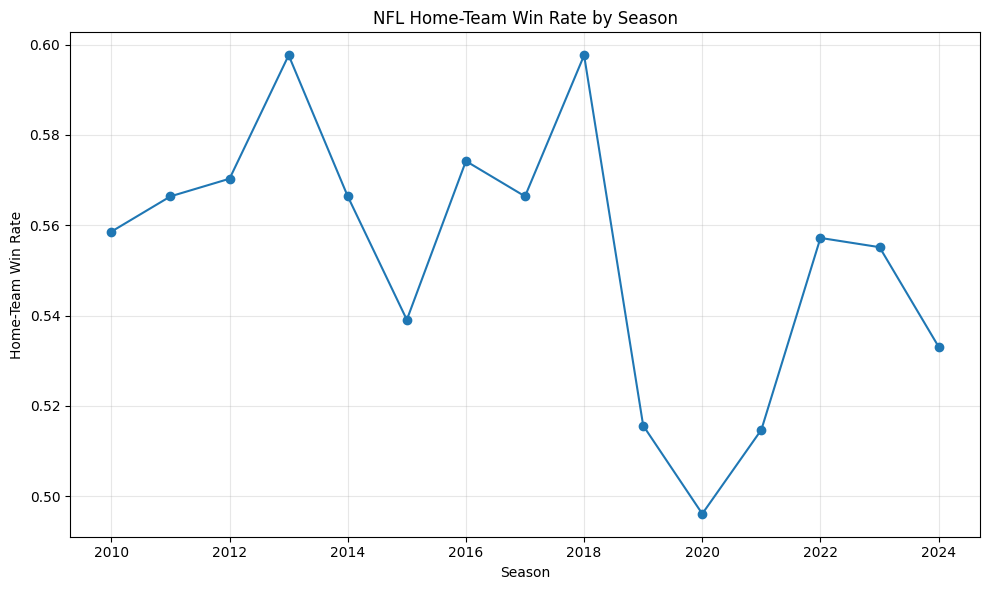

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(
    home_win_rate_by_season["season"],
    home_win_rate_by_season["home_win_rate"],
    marker="o"
)
plt.title("NFL Home-Team Win Rate by Season")
plt.xlabel("Season")
plt.ylabel("Home-Team Win Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/home_win_rate_by_season.png", dpi=300, bbox_inches="tight")
plt.show()

## Visualization 2: ROC Curve for the Final Model

This figure shows the final model’s ability to distinguish home-team wins from home-team losses across classification thresholds.

<Figure size 800x600 with 0 Axes>

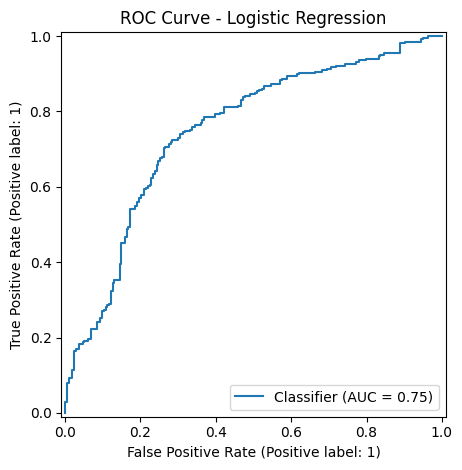

In [20]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title(f"ROC Curve - {final_name}")
plt.tight_layout()
plt.savefig("figures/model_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Visualization 3: Home-Team Win Rate by Spread Bucket

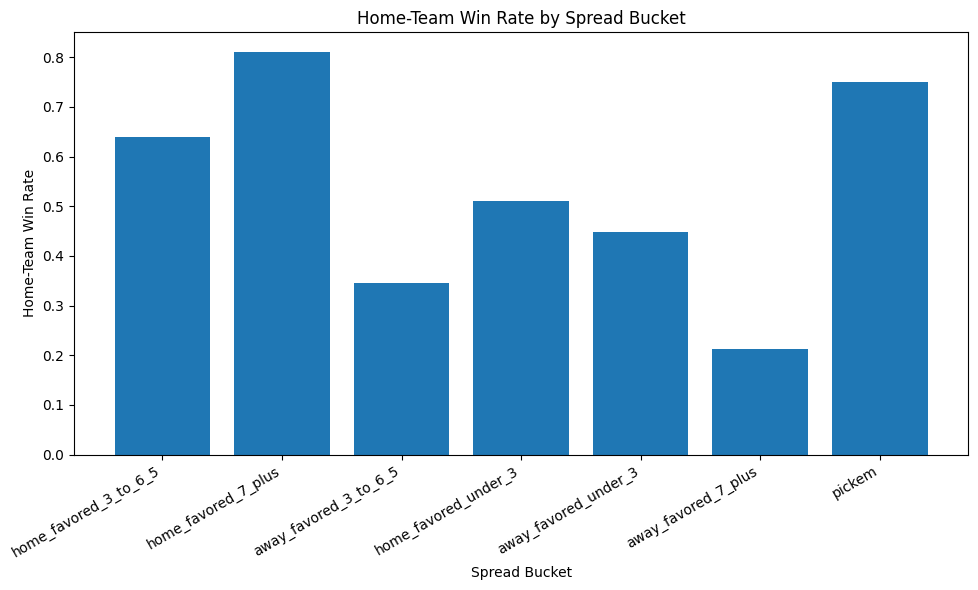

In [21]:
plt.figure(figsize=(10, 6))
plot_df = spread_bucket_summary.copy()
plt.bar(plot_df["spread_bucket"], plot_df["home_win_rate"])
plt.title("Home-Team Win Rate by Spread Bucket")
plt.xlabel("Spread Bucket")
plt.ylabel("Home-Team Win Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/home_win_rate_by_spread_bucket.png", dpi=300, bbox_inches="tight")
plt.show()

## Visualization rationale

I included one descriptive visualization and two analysis/model-focused visualizations. The season-level home-win chart explains the broad structure of the problem, the ROC curve shows the classification performance of the final model, and the spread-bucket chart demonstrates how strongly one of the native pregame market features relates to actual outcomes.